### This notebook will examine how much similar are L2reg and NNLS models and predictions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.summarize as ccs

/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


#### Load group models

In [15]:
train_ds_list = [ds+"_"+ses for ds, ses in zip(gl.datasets, gl.sessions)]

extention_list_1 = ["A0", "A0", "A0", "A2", "A0", "A0", "A0", "A2", "A2"]
extention_list_2 = ["A6", "A6", "A6", "A6", "A2", "A8", "A8", "A8", "A6"]
corr_list = []
for traindata, ext1, ext2 in zip(train_ds_list, extention_list_1, extention_list_2):
    model_NNLS, _ = ccs.get_model(traindata, 'Icosahedron1002', 'NNLS', ext1+"_group", cerebellum_atlas="MNISymC3")
    
    model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', ext2+"_group", cerebellum_atlas="MNISymC3")

    p = np.corrcoef(model_NNLS.coef_.flatten(), model_L2reg.coef_.flatten())[0, 1]
    corr_list.append(p)

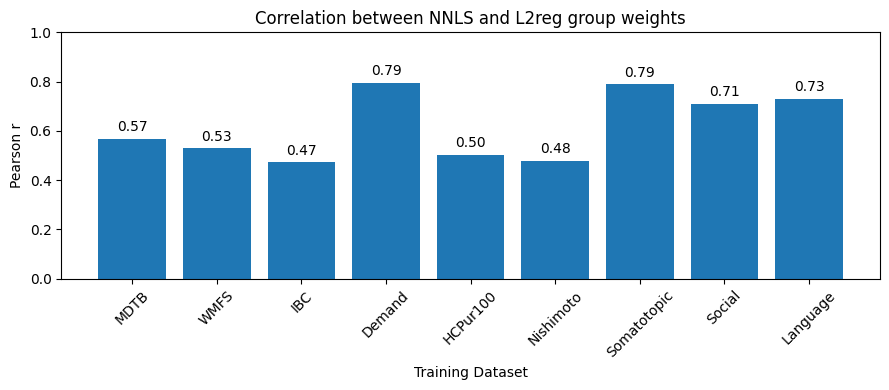

In [16]:
plt.figure(figsize=(9,4))
plt.bar(range(len(corr_list)), corr_list, color='C0')
plt.xlabel('Training Dataset')
plt.xticks(range(len(gl.datasets)), gl.datasets, rotation=45, ha='center')
plt.ylim(0, 1)
plt.ylabel('Pearson r')
plt.title('Correlation between NNLS and L2reg group weights')
for i, v in enumerate(corr_list):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

#### Load global models

In [17]:
train_ds_list = gl.get_ldo_names()
eval_ds_list = gl.datasets

extention_list_1 = ["A1", "A0", "A1", "A1", "A0", "A1", "", "A2", "A0"]
extention_list_2 = ["A2", "A2", "A4", "A2", "A2", "A4", "", "A2", "A2"]
corr_list_global = []
for traindata, ext1, ext2, ev_ds in zip(train_ds_list, extention_list_1, extention_list_2, eval_ds_list):
    if ext1 != "":
        model_NNLS, _ = ccs.get_model(traindata, 'Icosahedron1002', 'NNLS', ext1+"_global", cerebellum_atlas="MNISymC3")
    else:
        model_NNLS, _ = ccs.get_model(traindata, 'Icosahedron1002', 'NNLS', "global", cerebellum_atlas="MNISymC3")
    
    if ext2 != "":
        model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', ext2+"_global", cerebellum_atlas="MNISymC3")
    else:
        model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', "global", cerebellum_atlas="MNISymC3")

    p = np.corrcoef(model_NNLS.coef_.flatten(), model_L2reg.coef_.flatten())[0, 1]
    corr_list_global.append(p)

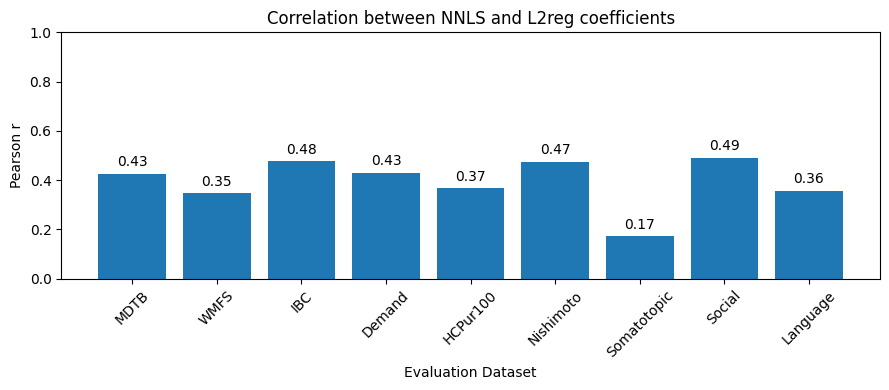

In [18]:
plt.figure(figsize=(9,4))
plt.bar(range(len(corr_list_global)), corr_list_global, color='C0')
plt.xlabel('Evaluation Dataset')
plt.xticks(range(len(eval_ds_list)), eval_ds_list, rotation=45, ha='center')
plt.ylim(0, 1)
plt.ylabel('Pearson r')
plt.title('Correlation between NNLS and L2reg coefficients')
for i, v in enumerate(corr_list_global):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()